# Specification Tests: Choosing the Right Model for Panel Data

**Notebook 03** | Diagnostics Module  
**Estimated Duration**: 110 minutes  
**Difficulty**: Intermediate

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the consistency vs. efficiency trade-off between FE and RE
2. **Apply** the Hausman test to choose between FE and RE models
3. **Interpret** Hausman test results and understand what rejection means
4. **Recognize** situations where the Hausman test may fail (singular matrix)
5. **Apply** the Davidson-MacKinnon J-test for non-nested model comparison
6. **Interpret** four possible outcomes of the J-test
7. **Use** specification tests to make informed modeling decisions

## Prerequisites
- Understanding of Fixed Effects (FE) and Random Effects (RE) models
- Familiarity with model comparison concepts
- Completion of static panel models tutorials

## Estimated Time per Section

| Section | Topic | Time |
|---------|-------|------|
| 1 | The FE vs RE Dilemma | 15 min |
| 2 | Hausman Test | 25 min |
| 3 | Davidson-MacKinnon J-Test | 25 min |
| 4 | Encompassing Tests | 10 min |
| 5 | Practical Applications | 20 min |
| 6 | Exercises | 15 min |
| 7 | Key Takeaways | 5 min |

## References

- **Hausman, J. A. (1978)**. "Specification tests in econometrics." *Econometrica*, 46(6), 1251-1271.
- **Davidson, R., & MacKinnon, J. G. (1981)**. "Several tests for model specification in the presence of alternative hypotheses." *Econometrica*, 49(3), 781-793.
- **Wooldridge, J. M. (2010)**. *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press. Chapter 10.
- **Mundlak, Y. (1978)**. "On the pooling of time series and cross section data." *Econometrica*, 46(1), 69-85.

In [1]:
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

from scipy import stats

# PanelBox imports
import panelbox
from panelbox.diagnostics.hausman import hausman_test
from panelbox.diagnostics.specification import (
    j_test,
    wald_encompassing_test,
)
from panelbox.models.static import FixedEffects, RandomEffects

# Configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "specification"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures" / "specification"
TABLES_DIR = OUTPUT_DIR / "tables" / "specification"
RESULTS_DIR = OUTPUT_DIR / "results" / "specification"

for d in [FIGURES_DIR, TABLES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"PanelBox version: {panelbox.__version__}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
PanelBox version: 1.0.0
Data directory: ../data/specification
Output directory: ../outputs


---

## Section 1: The FE vs RE Dilemma

### 1.1 Two Popular Panel Models

**Fixed Effects (FE)**:

$$y_{it} = X_{it}'\beta + \alpha_i + \varepsilon_{it}$$

- $\alpha_i$: entity-specific intercepts (treated as parameters)
- **Advantage**: Consistent even if $\alpha_i$ is correlated with $X_{it}$
- **Disadvantage**: Cannot estimate time-invariant effects; less efficient

**Random Effects (RE)**:

$$y_{it} = X_{it}'\beta + \alpha_i + \varepsilon_{it}, \quad \alpha_i \sim N(0, \sigma^2_\alpha)$$

- $\alpha_i$: random draws from a distribution
- **Advantage**: More efficient; can estimate time-invariant effects
- **Disadvantage**: Inconsistent if $\text{Cov}(\alpha_i, X_{it}) \neq 0$

### The Trade-off

| Criterion | FE | RE |
|-----------|----|----|
| **Consistency** | Always consistent | Only if $E[\alpha_i \| X_i] = 0$ |
| **Efficiency** | Less efficient | More efficient (under H0) |
| **Time-invariant vars** | Cannot estimate | Can estimate |

**Key question**: Is the orthogonality assumption $E[\alpha_i \| X_i] = 0$ reasonable?

### 1.2 Hausman Test Intuition

**Hausman (1978) insight**: Compare two estimators:
1. One always consistent but inefficient (FE)
2. One efficient but potentially inconsistent (RE)

**If orthogonality holds** (H0 true):
- Both are consistent → they converge to the same $\beta$
- Difference $\hat{\beta}_{FE} - \hat{\beta}_{RE}$ is "small" (just sampling variation)

**If orthogonality fails** (H0 false):
- FE still consistent, RE is inconsistent
- Difference $\hat{\beta}_{FE} - \hat{\beta}_{RE}$ is "large" and systematic

**Test statistic**:

$$H = (\hat{\beta}_{FE} - \hat{\beta}_{RE})' \left[\text{Var}(\hat{\beta}_{FE}) - \text{Var}(\hat{\beta}_{RE})\right]^{-1} (\hat{\beta}_{FE} - \hat{\beta}_{RE})$$

Under H0: $H \sim \chi^2(k)$, where $k$ = number of common time-varying regressors.

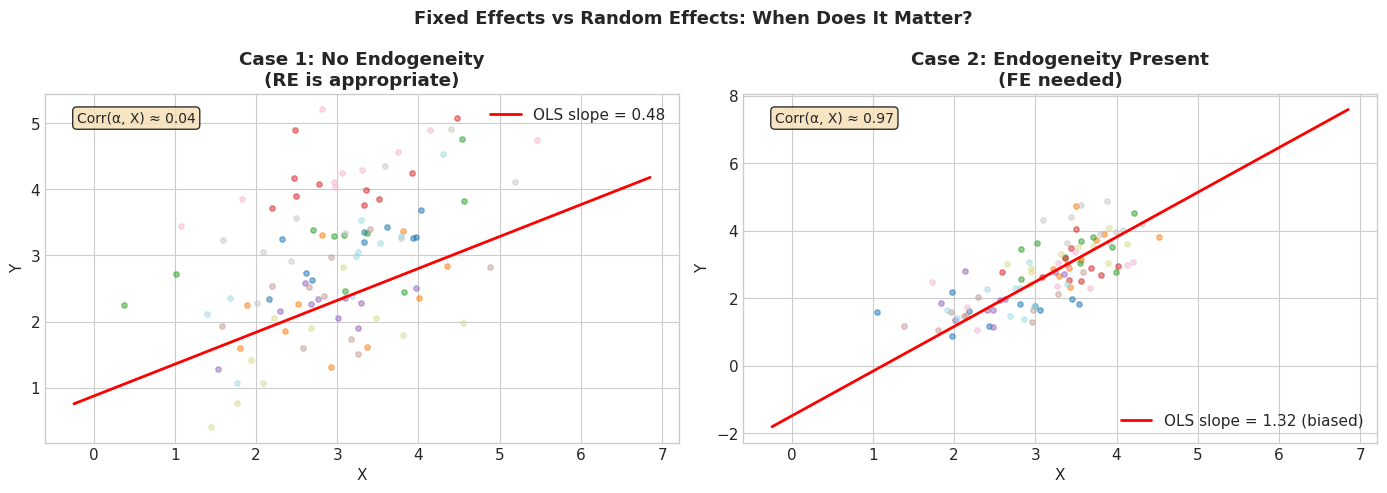

True slope β = 0.5
Case 1 (no endogeneity): OLS slope ≈ 0.483
Case 2 (endogeneity):    OLS slope ≈ 1.323 (biased upward)

In Case 2, OLS/RE confounds the effect of X with the effect of α (ability).


In [2]:
# Visualize the FE vs RE trade-off with simulated data
np.random.seed(42)
N, T = 50, 10

# Case 1: alpha uncorrelated with X (RE is appropriate)
alpha_1 = np.random.normal(0, 1, N)
x_1 = np.random.normal(3, 1, (N, T))
y_1 = np.zeros((N, T))
for i in range(N):
    for t in range(T):
        y_1[i, t] = 1 + 0.5 * x_1[i, t] + alpha_1[i] + np.random.normal(0, 0.5)

# Case 2: alpha correlated with X (FE needed)
alpha_2 = np.random.normal(0, 1, N)
x_2 = np.zeros((N, T))
for i in range(N):
    x_2[i, :] = 3 + 0.8 * alpha_2[i] + np.random.normal(0, 0.5, T)
y_2 = np.zeros((N, T))
for i in range(N):
    for t in range(T):
        y_2[i, t] = 1 + 0.5 * x_2[i, t] + alpha_2[i] + np.random.normal(0, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Case 1
colors = plt.cm.tab20(np.linspace(0, 1, min(N, 10)))
for i in range(min(N, 10)):
    axes[0].scatter(x_1[i], y_1[i], alpha=0.5, s=15, color=colors[i])
# Overall OLS line
x_flat = x_1.flatten()
y_flat = y_1.flatten()
slope, intercept = np.polyfit(x_flat, y_flat, 1)
x_line = np.linspace(x_flat.min(), x_flat.max(), 100)
axes[0].plot(
    x_line, intercept + slope * x_line, "r-", linewidth=2, label=f"OLS slope = {slope:.2f}"
)
axes[0].set_title("Case 1: No Endogeneity\n(RE is appropriate)", fontweight="bold")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].legend()
axes[0].text(
    0.05,
    0.95,
    f"Corr(α, X) ≈ {np.corrcoef(alpha_1, x_1.mean(axis=1))[0, 1]:.2f}",
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox={"boxstyle": "round", "facecolor": "wheat", "alpha": 0.8},
)

# Plot Case 2
for i in range(min(N, 10)):
    axes[1].scatter(x_2[i], y_2[i], alpha=0.5, s=15, color=colors[i])
x_flat = x_2.flatten()
y_flat = y_2.flatten()
slope, intercept = np.polyfit(x_flat, y_flat, 1)
axes[1].plot(
    x_line, intercept + slope * x_line, "r-", linewidth=2, label=f"OLS slope = {slope:.2f} (biased)"
)
axes[1].set_title("Case 2: Endogeneity Present\n(FE needed)", fontweight="bold")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].legend()
axes[1].text(
    0.05,
    0.95,
    f"Corr(α, X) ≈ {np.corrcoef(alpha_2, x_2.mean(axis=1))[0, 1]:.2f}",
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox={"boxstyle": "round", "facecolor": "wheat", "alpha": 0.8},
)

plt.suptitle(
    "Fixed Effects vs Random Effects: When Does It Matter?", fontweight="bold", fontsize=13
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_fe_vs_re_intuition.png", dpi=300, bbox_inches="tight")
plt.show()

print("True slope β = 0.5")
print(f"Case 1 (no endogeneity): OLS slope ≈ {np.polyfit(x_1.flatten(), y_1.flatten(), 1)[0]:.3f}")
print(
    f"Case 2 (endogeneity):    OLS slope ≈ {np.polyfit(x_2.flatten(), y_2.flatten(), 1)[0]:.3f} (biased upward)"
)
print("\nIn Case 2, OLS/RE confounds the effect of X with the effect of α (ability).")

### 1.3 Economic Interpretation

**Example: Wage Equation**

$$\log(\text{wage}_{it}) = \beta_1 \cdot \text{experience}_{it} + \beta_2 \cdot \text{tenure}_{it} + \alpha_i + \varepsilon_{it}$$

- $\alpha_i$: unobserved ability
- **Issue**: More able workers may accumulate experience faster → $\text{Cov}(\alpha_i, \text{experience}_{it}) > 0$
- **RE consequence**: Overestimates the return to experience (confounds with ability)
- **Hausman test**: Should reject H0 → use FE

**Example: Country Growth** (when RE might be OK)

$$\text{growth}_{it} = \beta_1 \cdot \text{investment}_{it} + \beta_2 \cdot \text{education}_{it} + \alpha_i + \varepsilon_{it}$$

- $\alpha_i$: institutions, geography
- **If** institutions are exogenous to current investment → $\text{Cov}(\alpha_i, X_{it}) \approx 0$
- **Hausman test**: May not reject → RE provides more efficient estimates

---

## Section 2: Hausman Test

### 2.1 Test Procedure

**Steps:**
1. Estimate Fixed Effects model
2. Estimate Random Effects model
3. Compute Hausman statistic from the coefficient differences
4. Compare to $\chi^2$ distribution

Let's apply this to wage data where we expect the unobserved individual effect (ability) to be correlated with experience and tenure.

In [3]:
# Load NLS Women's data (simulated)
nls = pd.read_csv(DATA_DIR / "nlswork.csv")

print("NLS Work Panel Data")
print("=" * 60)
print(f"Shape: {nls.shape}")
print(f"Workers: {nls['idcode'].nunique()}")
print(f"Years: {sorted(nls['year'].unique())}")
print("\nVariable descriptions:")
desc = {
    "idcode": "Worker identifier",
    "year": "Survey year",
    "ln_wage": "Log hourly wage",
    "experience": "Years of work experience",
    "tenure": "Years with current employer",
    "education": "Years of education",
    "union": "Union membership (0/1)",
    "married": "Marital status (0/1)",
    "hours": "Weekly hours worked",
    "industry": "Industry code",
}
for var, d in desc.items():
    print(f"  {var:15s}: {d}")

print("\nSummary statistics:")
display(nls.describe().round(3))

NLS Work Panel Data
Shape: (7500, 10)
Workers: 500
Years: [np.int64(1968), np.int64(1970), np.int64(1972), np.int64(1974), np.int64(1976), np.int64(1978), np.int64(1980), np.int64(1982), np.int64(1984), np.int64(1986), np.int64(1988), np.int64(1990), np.int64(1992), np.int64(1994), np.int64(1996)]

Variable descriptions:
  idcode         : Worker identifier
  year           : Survey year
  ln_wage        : Log hourly wage
  experience     : Years of work experience
  tenure         : Years with current employer
  education      : Years of education
  union          : Union membership (0/1)
  married        : Marital status (0/1)
  hours          : Weekly hours worked
  industry       : Industry code

Summary statistics:


,idcode,year,ln_wage,experience,tenure,education,union,married,hours,industry
count,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000,7500.000
mean,250.500,1982.000,1.795,13.453,2.039,11.730,0.245,0.548,40.152,6.504
std,144.347,8.642,0.557,6.664,2.042,2.099,0.430,0.498,4.915,3.448
min,1.000,1968.000,-0.673,0.500,0.100,8.000,0.000,0.000,19.700,1.000
25%,125.750,1974.000,1.427,7.918,0.617,10.000,0.000,0.000,36.900,3.000
50%,250.500,1982.000,1.810,13.500,1.440,12.000,0.000,1.000,40.200,7.000
75%,375.250,1990.000,2.179,19.080,2.840,13.000,0.000,1.000,43.500,9.000
max,500.000,1996.000,3.790,28.070,19.880,18.000,1.000,1.000,57.700,12.000


In [4]:
# Step 1: Estimate Fixed Effects model (time-varying variables only)
fe_model = FixedEffects(
    "ln_wage ~ experience + tenure + union + married",
    data=nls,
    entity_col="idcode",
    time_col="year",
)
fe_result = fe_model.fit()

print("Fixed Effects Estimation")
print("=" * 60)
print(fe_result.summary())

Fixed Effects Estimation
                       Fixed Effects Estimation Results                       
Formula: ln_wage ~ experience + tenure + union + married
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:               7,500
No. Entities:                     500
No. Time Periods:                  15
Degrees of Freedom:             6,996
R-squared:                     0.1987
Adj. R-squared:                0.1411
R-squared (within):            0.1987
R-squared (between):           1.0000
R-squared (overall):           0.7323
Standard Errors:            nonrobust
F-statistic (FE vs OLS):      31.4681
F-test p-value:                0.0000
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
experience           0.0198      0.0005  36.929  0.0000    0.0188    0.0209 ***
tenure               0.0158      0.0018 

In [5]:
# Step 2: Estimate Random Effects model (can include education - time-invariant)
re_model = RandomEffects(
    "ln_wage ~ experience + tenure + union + married + education",
    data=nls,
    entity_col="idcode",
    time_col="year",
)
re_result = re_model.fit()

print("Random Effects Estimation")
print("=" * 60)
print(re_result.summary())

print(
    f"\nNote: Education coefficient (only estimable with RE): {re_result.params['education']:.4f}"
)
print(
    f"  Interpretation: {re_result.params['education'] * 100:.2f}% wage increase per year of education"
)

Random Effects Estimation
                   Random Effects (GLS) Estimation Results                    
Formula: ln_wage ~ experience + tenure + union + married + education
Model:   Random Effects (GLS)
------------------------------------------------------------------------------
No. Observations:               7,500
No. Entities:                     500
No. Time Periods:                  15
Degrees of Freedom:             7,494
R-squared:                     0.2538
Adj. R-squared:                0.2533
R-squared (within):            0.2054
R-squared (between):           0.2817
R-squared (overall):           0.2538
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept            0.2562      0.0177  14.501  0.0000    0.2216    0.2909 ***
experience           0.0203      0.0005  37.179  0.0000    0.0192    0.0214 ***
tenure          

In [6]:
# Step 3: Hausman test
hausman_result = hausman_test(fe_result, re_result)
hausman_result.summary()


Hausman Specification Test
H0: Random Effects estimator is consistent and efficient
H1: Random Effects estimator is inconsistent

Test statistic: 58.2526
P-value: 0.0000
Degrees of freedom: 4
Method: chi2

----------------------------------------
Interpretation:
Reject H0: Random Effects estimator appears inconsistent (p=0.0000).
Fixed Effects is preferred. This suggests correlation between
unobserved heterogeneity and regressors.

Strong evidence against Random Effects (p < 0.01)

Variables compared: experience, married, tenure, union


### 2.2 Interpreting the Results

The Hausman test compares the coefficients of **common time-varying variables** between FE and RE. Let's examine the coefficient differences in detail.

In [7]:
# Detailed coefficient comparison
common_vars = hausman_result.common_vars
comparison = pd.DataFrame(
    {
        "FE Estimate": fe_result.params[common_vars],
        "RE Estimate": re_result.params[common_vars],
        "Difference": fe_result.params[common_vars] - re_result.params[common_vars],
        "FE Std.Err": fe_result.std_errors[common_vars],
        "RE Std.Err": re_result.std_errors[common_vars],
    }
)
comparison["Rel. Diff (%)"] = (comparison["Difference"] / comparison["FE Estimate"] * 100).round(1)

print("Coefficient Comparison: FE vs RE")
print("=" * 70)
display(comparison.round(6))
comparison.to_csv(TABLES_DIR / "03_hausman_coefficient_comparison.csv")

print(f"\nHausman statistic: {hausman_result.statistic:.4f}")
print(f"P-value: {hausman_result.pvalue:.6f}")
print(f"Degrees of freedom: {hausman_result.df}")

if hausman_result.pvalue < 0.05:
    print("\n→ REJECT H0: Use Fixed Effects")
    print("  Interpretation: Unobserved ability is correlated with regressors")
    print("  The RE estimator is inconsistent.")
    print(f"  Note: Education effect ({re_result.params['education']:.4f}) from RE may be biased.")
else:
    print("\n→ FAIL TO REJECT H0: Random Effects is acceptable")
    print("  Interpretation: No evidence of correlation between effects and regressors")
    print("  RE is more efficient and can estimate time-invariant effects.")

Coefficient Comparison: FE vs RE


,FE Estimate,RE Estimate,Difference,FE Std.Err,RE Std.Err,Rel. Diff (%)
experience,0.0198,0.0203,-4.8600e-04,0.0005,0.0005,-2.5
married,0.0399,0.0398,9.3000e-05,0.0072,0.0071,0.2
tenure,0.0158,0.0173,-1.4960e-03,0.0018,0.0017,-9.5
union,0.1034,0.0932,1.0159e-02,0.0084,0.0081,9.8



Hausman statistic: 58.2526
P-value: 0.000000
Degrees of freedom: 4

→ REJECT H0: Use Fixed Effects
  Interpretation: Unobserved ability is correlated with regressors
  The RE estimator is inconsistent.
  Note: Education effect (0.1011) from RE may be biased.


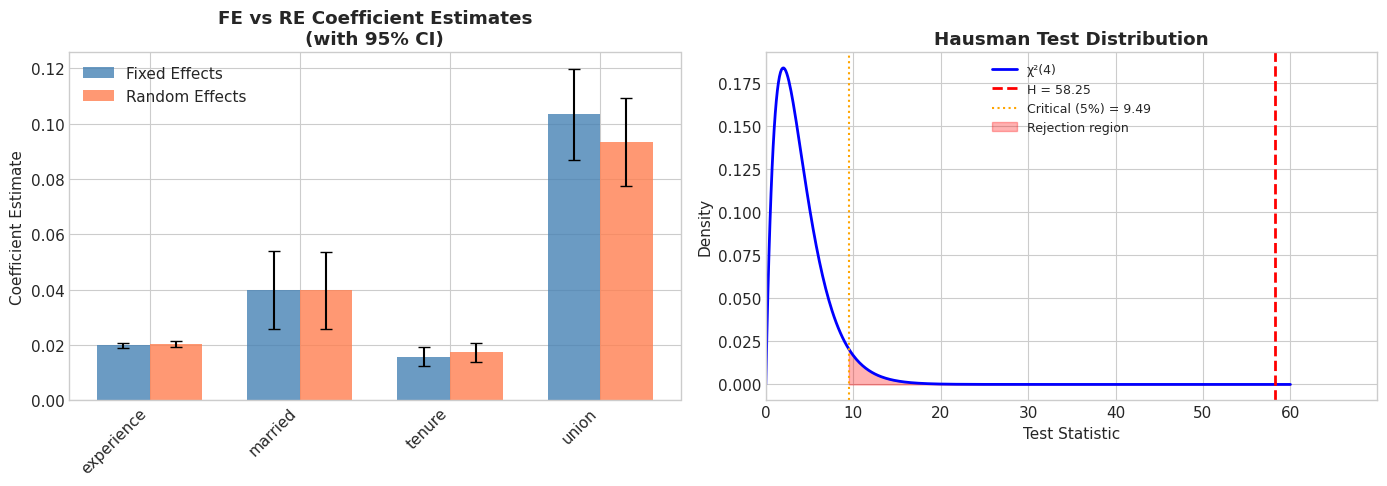

In [8]:
# Visualize the Hausman test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Coefficient comparison
vars_to_plot = common_vars
x = np.arange(len(vars_to_plot))
width = 0.35

fe_vals = [fe_result.params[v] for v in vars_to_plot]
re_vals = [re_result.params[v] for v in vars_to_plot]
fe_errs = [1.96 * fe_result.std_errors[v] for v in vars_to_plot]
re_errs = [1.96 * re_result.std_errors[v] for v in vars_to_plot]

axes[0].bar(
    x - width / 2,
    fe_vals,
    width,
    yerr=fe_errs,
    label="Fixed Effects",
    color="steelblue",
    alpha=0.8,
    capsize=4,
)
axes[0].bar(
    x + width / 2,
    re_vals,
    width,
    yerr=re_errs,
    label="Random Effects",
    color="coral",
    alpha=0.8,
    capsize=4,
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(vars_to_plot, rotation=45, ha="right")
axes[0].set_ylabel("Coefficient Estimate")
axes[0].set_title("FE vs RE Coefficient Estimates\n(with 95% CI)", fontweight="bold")
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")

# Panel 2: Chi-squared distribution
x_chi = np.linspace(0, 60, 500)
y_chi = stats.chi2.pdf(x_chi, hausman_result.df)
axes[1].plot(x_chi, y_chi, "b-", linewidth=2, label=f"χ²({hausman_result.df})")
axes[1].axvline(
    hausman_result.statistic,
    color="red",
    linewidth=2,
    linestyle="--",
    label=f"H = {hausman_result.statistic:.2f}",
)
critical = stats.chi2.ppf(0.95, hausman_result.df)
axes[1].axvline(
    critical, color="orange", linewidth=1.5, linestyle=":", label=f"Critical (5%) = {critical:.2f}"
)
axes[1].fill_between(
    x_chi[x_chi > critical],
    y_chi[x_chi > critical],
    alpha=0.3,
    color="red",
    label="Rejection region",
)
axes[1].set_xlabel("Test Statistic")
axes[1].set_ylabel("Density")
axes[1].set_title("Hausman Test Distribution", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, max(60, hausman_result.statistic * 1.2))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_hausman_test_results.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.3 Handling Common Issues

#### Issue 1: Singular Variance Matrix

The variance difference matrix $V_{FE} - V_{RE}$ should be positive semi-definite, but sometimes isn't due to:
- Finite sample issues
- Small within-variation
- Few time periods

When this happens, the Hausman statistic can be negative (meaningless). The function uses a pseudo-inverse as fallback.

#### Issue 2: Important Caveats

1. **Failure to reject ≠ proof that RE is correct**: The test may have low power
2. **Only compares common time-varying coefficients**: Time-invariant variables (like education) are excluded from the test
3. **Assumes correct model specification**: Both models must be properly specified
4. **Sensitive to sample size**: Large samples almost always reject

Let's demonstrate the singular matrix issue with a simulated example.

In [9]:
# Demonstrate singular matrix issue with small within-variation
np.random.seed(123)
N_small, T_small = 30, 5
records = []
for i in range(1, N_small + 1):
    alpha = np.random.normal(0, 2)  # Large FE
    for t in range(T_small):
        x1 = np.random.normal(5, 0.1)  # Very small within-variation!
        x2 = np.random.normal(3, 1)
        y = 1 + 0.5 * x1 + 0.3 * x2 + alpha + np.random.normal(0, 0.5)
        records.append(
            {"entity": i, "time": t, "y": round(y, 4), "x1": round(x1, 4), "x2": round(x2, 4)}
        )

df_small = pd.DataFrame(records)

fe_small = FixedEffects("y ~ x1 + x2", df_small, "entity", "time").fit()
re_small = RandomEffects("y ~ x1 + x2", df_small, "entity", "time").fit()

# Hausman test - may have singular matrix
import warnings

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    h_small = hausman_test(fe_small, re_small)

    if w:
        print("⚠ Warnings encountered:")
        for warning in w:
            print(f"  {warning.message}")

    print(f"\nHausman statistic: {h_small.statistic:.4f}")
    print(f"P-value: {h_small.pvalue:.4f}")

    # Check eigenvalues
    common = h_small.common_vars
    V_diff = (
        fe_small.cov_params.loc[common, common].values
        - re_small.cov_params.loc[common, common].values
    )
    eigs = np.linalg.eigvalsh(V_diff)
    print(f"\nEigenvalues of V_FE - V_RE: {eigs}")
    if any(e < -1e-8 for e in eigs):
        print("→ Matrix is NOT positive semi-definite!")
        print("  The Hausman test may be unreliable.")
        print("  Consider: larger sample, different specification, or alternative tests.")
    else:
        print("→ Matrix is positive semi-definite (test is valid)")

⚠ Warnings encountered:
  Variance difference matrix is not positive semi-definite. This may indicate model misspecification. Minimum eigenvalue: -2.72e-05

Hausman statistic: -0.7146
P-value: 1.0000

Eigenvalues of V_FE - V_RE: [-2.71839399e-05  2.67387390e-01]
→ Matrix is NOT positive semi-definite!
  The Hausman test may be unreliable.
  Consider: larger sample, different specification, or alternative tests.


---

## Section 3: Davidson-MacKinnon J-Test

### 3.1 Non-Nested Model Comparison

The Hausman test compares FE vs RE for the **same specification**. But what if we want to compare models with **different regressors** that aren't nested?

**Example**:
- Model 1: $\log(Y) = \beta_1 \log(K) + \beta_2 \log(L) + \varepsilon$
- Model 2: $\log(Y) = \gamma_1 \log(K) + \gamma_2 \log(L) + \gamma_3 \log(M) + \varepsilon$

Model 1 is nested in Model 2 (add $\gamma_3 = 0$), so a Wald/F-test suffices. But for truly non-nested models:

- Model A: $y \sim x_1 + x_2$
- Model B: $y \sim x_1 + x_3$

Neither is a special case of the other → Cannot use LR/Wald tests.

### 3.2 J-Test Procedure

**Idea**: Augment each model with **fitted values** from the other.

**Forward test** (H0: Model 1 is correct):
$$y = X_1 \beta + \alpha \cdot \hat{y}_2 + \varepsilon$$
If $\alpha \neq 0$: Model 2's predictions add information → Model 1 is incomplete.

**Reverse test** (H0: Model 2 is correct):
$$y = X_2 \gamma + \delta \cdot \hat{y}_1 + \varepsilon$$
If $\delta \neq 0$: Model 1's predictions add information → Model 2 is incomplete.

### 3.3 Four Possible Outcomes

| Forward (M1) | Reverse (M2) | Interpretation |
|:---:|:---:|:---|
| Don't reject | Don't reject | **Both adequate** — equivalent for this data |
| **Reject** | Don't reject | **Prefer Model 2** — has extra information |
| Don't reject | **Reject** | **Prefer Model 1** — has extra information |
| **Reject** | **Reject** | **Both inadequate** — need a more general model |

In [10]:
# Load firm productivity data
firm = pd.read_csv(DATA_DIR / "firm_productivity.csv")

print("Firm Productivity Panel Data")
print("=" * 60)
print(f"Shape: {firm.shape}")
print(f"Firms: {firm['firm_id'].nunique()}")
print(f"Years: {firm['year'].min()} - {firm['year'].max()}")
print(f"Sectors: {firm['sector'].unique()}")
print("\nSummary statistics:")
display(
    firm[["log_output", "log_capital", "log_labor", "log_materials", "rd_intensity"]]
    .describe()
    .round(3)
)

Firm Productivity Panel Data
Shape: (4000, 9)
Firms: 200
Years: 2000 - 2019
Sectors: ['Technology' 'Manufacturing' 'Energy' 'Services']

Summary statistics:


,log_output,log_capital,log_labor,log_materials,rd_intensity
count,4000.000,4000.000,4000.000,4000.000,4000.000
mean,7.017,9.173,5.089,7.663,0.031
std,0.528,1.025,0.516,0.788,0.019
min,5.182,5.772,3.318,4.740,0.000
25%,6.654,8.489,4.755,7.151,0.017
50%,7.025,9.169,5.104,7.677,0.031
75%,7.377,9.868,5.442,8.187,0.044
max,8.884,12.921,6.773,10.407,0.104


In [11]:
# Estimate three production function specifications
# Model A: Basic Cobb-Douglas
m_a = FixedEffects(
    "log_output ~ log_capital + log_labor", data=firm, entity_col="firm_id", time_col="year"
)
result_a = m_a.fit()

# Model B: Cobb-Douglas with Materials
m_b = FixedEffects(
    "log_output ~ log_capital + log_labor + log_materials",
    data=firm,
    entity_col="firm_id",
    time_col="year",
)
result_b = m_b.fit()

# Model C: Full specification with R&D
m_c = FixedEffects(
    "log_output ~ log_capital + log_labor + log_materials + rd_intensity",
    data=firm,
    entity_col="firm_id",
    time_col="year",
)
result_c = m_c.fit()

# Summary table
model_comp = pd.DataFrame(
    {
        "Model A (K,L)": result_a.params,
        "Model B (K,L,M)": result_b.params,
        "Model C (K,L,M,R&D)": result_c.params,
    }
)
model_comp = model_comp.fillna("")

print("Production Function Estimates (Fixed Effects)")
print("=" * 60)
display(model_comp.round(4))

# R-squared comparison
print("\nWithin R²:")
print(f"  Model A: {result_a.rsquared_within:.4f}")
print(f"  Model B: {result_b.rsquared_within:.4f}")
print(f"  Model C: {result_c.rsquared_within:.4f}")

Production Function Estimates (Fixed Effects)


,"Model A (K,L)","Model B (K,L,M)","Model C (K,L,M,R&D)"
log_capital,0.2988,0.2988,0.2989
log_labor,0.3563,0.3495,0.3494
log_materials,,0.2497,0.2496
rd_intensity,,,0.4503



Within R²:
  Model A: 0.7249
  Model B: 0.9430
  Model C: 0.9434


In [12]:
# J-test: Model A vs Model B
print("J-Test: Model A (K,L) vs Model B (K,L,M)")
print("=" * 60)
jtest_ab = j_test(
    result_a, result_b, model1_name="Cobb-Douglas (K,L)", model2_name="With Materials (K,L,M)"
)

print(jtest_ab.interpretation())
print("\nSummary Table:")
display(jtest_ab.summary().round(4))

J-Test: Model A (K,L) vs Model B (K,L,M)
J-Test Results (Both Directions):

Forward Test (Cobb-Douglas (K,L) vs With Materials (K,L,M)):
  H0: Cobb-Douglas (K,L) is correct
  p-value = 0.0000
  Result: REJECT H0

Reverse Test (With Materials (K,L,M) vs Cobb-Douglas (K,L)):
  H0: With Materials (K,L,M) is correct
  p-value = 0.0000
  Result: REJECT H0

Overall Interpretation:
------------------------------------------------------------
BOTH MODELS REJECTED
  - Neither model adequately encompasses the other
  - Both models have explanatory power the other lacks
  - Consider a more comprehensive specification


Summary Table:


,Test,Null Hypothesis,Test Statistic,p-value,Coefficient,Std. Error
0,Forward,"Cobb-Douglas (K,L) is correct",256.7689,0.0,1.0000,0.0039
1,Reverse,"With Materials (K,L,M) is correct",123.8651,0.0,0.8434,0.0068


In [13]:
# J-test: Model B vs Model C
print("J-Test: Model B (K,L,M) vs Model C (K,L,M,R&D)")
print("=" * 60)
jtest_bc = j_test(
    result_b, result_c, model1_name="With Materials (K,L,M)", model2_name="Full (K,L,M,R&D)"
)

print(jtest_bc.interpretation())
print("\nSummary Table:")
display(jtest_bc.summary().round(4))

J-Test: Model B (K,L,M) vs Model C (K,L,M,R&D)
J-Test Results (Both Directions):

Forward Test (With Materials (K,L,M) vs Full (K,L,M,R&D)):
  H0: With Materials (K,L,M) is correct
  p-value = 0.0000
  Result: REJECT H0

Reverse Test (Full (K,L,M,R&D) vs With Materials (K,L,M)):
  H0: Full (K,L,M,R&D) is correct
  p-value = 0.0000
  Result: REJECT H0

Overall Interpretation:
------------------------------------------------------------
BOTH MODELS REJECTED
  - Neither model adequately encompasses the other
  - Both models have explanatory power the other lacks
  - Consider a more comprehensive specification


Summary Table:


,Test,Null Hypothesis,Test Statistic,p-value,Coefficient,Std. Error
0,Forward,"With Materials (K,L,M) is correct",192.6784,0.0,1.0000,0.0052
1,Reverse,"Full (K,L,M,R&D) is correct",188.4383,0.0,0.9954,0.0053


In [14]:
# Save J-test results
jtest_summary = pd.DataFrame(
    {
        "Comparison": ["A vs B", "B vs C"],
        "Forward p-value": [jtest_ab.forward["pvalue"], jtest_bc.forward["pvalue"]],
        "Reverse p-value": [jtest_ab.reverse["pvalue"], jtest_bc.reverse["pvalue"]],
        "Forward Reject": [jtest_ab.forward["pvalue"] < 0.05, jtest_bc.forward["pvalue"] < 0.05],
        "Reverse Reject": [jtest_ab.reverse["pvalue"] < 0.05, jtest_bc.reverse["pvalue"] < 0.05],
    }
)

# Determine outcome
outcomes = []
for _, row in jtest_summary.iterrows():
    if row["Forward Reject"] and not row["Reverse Reject"]:
        outcomes.append("Prefer Model 2")
    elif not row["Forward Reject"] and row["Reverse Reject"]:
        outcomes.append("Prefer Model 1")
    elif row["Forward Reject"] and row["Reverse Reject"]:
        outcomes.append("Both rejected")
    else:
        outcomes.append("Both acceptable")
jtest_summary["Outcome"] = outcomes

print("J-Test Results Summary")
print("=" * 60)
display(jtest_summary)
jtest_summary.to_csv(TABLES_DIR / "03_jtest_results.csv", index=False)

J-Test Results Summary


,Comparison,Forward p-value,Reverse p-value,Forward Reject,Reverse Reject,Outcome
0,A vs B,0.0,0.0,True,True,Both rejected
1,B vs C,0.0,0.0,True,True,Both rejected


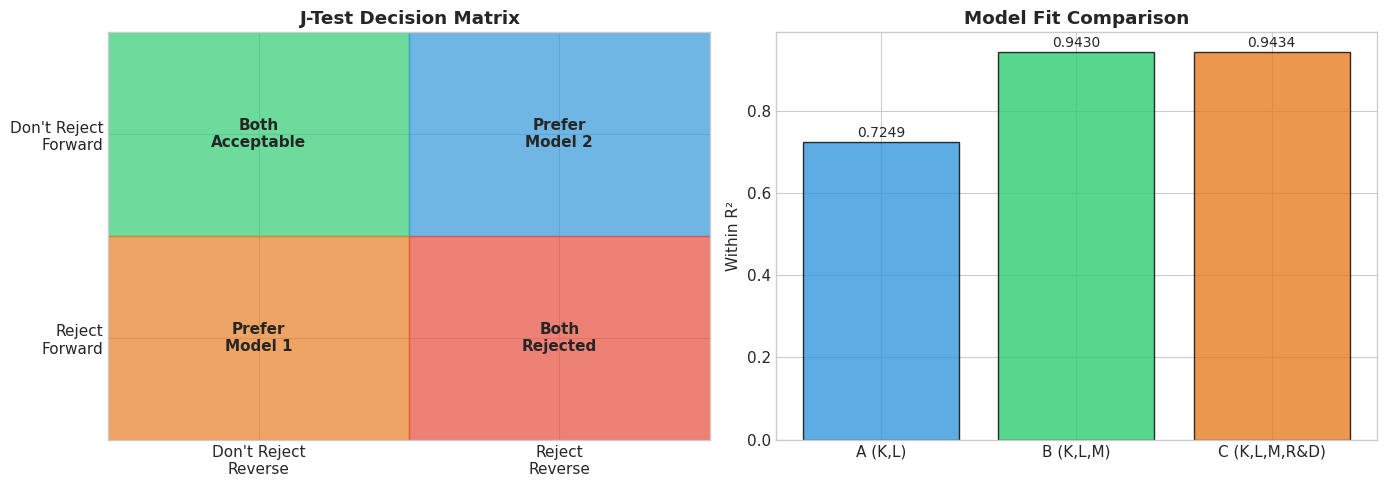

In [15]:
# Visualize J-test outcomes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: J-test decision matrix
decision_matrix = np.array(
    [
        [0, 1],  # Don't reject both = green, Reject fwd only = blue
        [2, 3],  # Reject rev only = orange, Reject both = red
    ]
)
colors_matrix = np.array([["#2ecc71", "#3498db"], ["#e67e22", "#e74c3c"]])
labels_matrix = np.array(
    [["Both\nAcceptable", "Prefer\nModel 2"], ["Prefer\nModel 1", "Both\nRejected"]]
)

for i in range(2):
    for j in range(2):
        axes[0].add_patch(
            plt.Rectangle((j, 1 - i), 1, 1, fill=True, color=colors_matrix[i][j], alpha=0.7)
        )
        axes[0].text(
            j + 0.5,
            1.5 - i,
            labels_matrix[i][j],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

axes[0].set_xlim(0, 2)
axes[0].set_ylim(0, 2)
axes[0].set_xticks([0.5, 1.5])
axes[0].set_xticklabels(["Don't Reject\nReverse", "Reject\nReverse"])
axes[0].set_yticks([0.5, 1.5])
axes[0].set_yticklabels(["Reject\nForward", "Don't Reject\nForward"])
axes[0].set_title("J-Test Decision Matrix", fontweight="bold")

# Panel 2: Model comparison bar chart
models = ["A (K,L)", "B (K,L,M)", "C (K,L,M,R&D)"]
r2_vals = [result_a.rsquared_within, result_b.rsquared_within, result_c.rsquared_within]
bars = axes[1].bar(
    models, r2_vals, color=["#3498db", "#2ecc71", "#e67e22"], alpha=0.8, edgecolor="black"
)
axes[1].set_ylabel("Within R²")
axes[1].set_title("Model Fit Comparison", fontweight="bold")
for bar, val in zip(bars, r2_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_jtest_results.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Section 4: Encompassing Tests

### 4.1 Wald Encompassing Test

For **nested** models (one is a special case of the other), we can use the Wald encompassing test. This tests whether the additional variables in the unrestricted model are jointly significant.

$$W = (\hat{\beta}_r)' [\text{Var}(\hat{\beta}_r)]^{-1} (\hat{\beta}_r) \sim \chi^2(q)$$

where $q$ is the number of restrictions (additional variables).

In [16]:
# Wald encompassing test: Model A (restricted) vs Model B (unrestricted)
print("Wald Encompassing Test: Model A vs Model B")
print("=" * 60)
wald_result = wald_encompassing_test(
    result_a,
    result_b,
    model_restricted_name="Cobb-Douglas (K,L)",
    model_unrestricted_name="With Materials (K,L,M)",
)

print(wald_result.interpretation())
print("\nAdditional info:")
print(f"  Restricted params: {wald_result.additional_info['k_restricted']}")
print(f"  Unrestricted params: {wald_result.additional_info['k_unrestricted']}")
print(f"  Number of restrictions: {wald_result.additional_info['num_restrictions']}")

Wald Encompassing Test: Model A vs Model B
Wald Encompassing Test

H0: Cobb-Douglas (K,L) is adequate (restrictions valid)
Ha: With Materials (K,L,M) significantly improves fit

Test statistic: 15292.1779
Degrees of freedom: 1
p-value: 0.0000

Decision:
------------------------------------------------------------
REJECT H0 at 0.05 level (p=0.0000 < 0.05)
With Materials (K,L,M) significantly improves fit


Additional info:
  Restricted params: 2
  Unrestricted params: 3
  Number of restrictions: 1


In [17]:
# Wald encompassing test: Model B vs Model C
print("Wald Encompassing Test: Model B vs Model C")
print("=" * 60)
wald_result_bc = wald_encompassing_test(
    result_b,
    result_c,
    model_restricted_name="With Materials (K,L,M)",
    model_unrestricted_name="Full (K,L,M,R&D)",
)

print(wald_result_bc.interpretation())

Wald Encompassing Test: Model B vs Model C
Wald Encompassing Test

H0: With Materials (K,L,M) is adequate (restrictions valid)
Ha: Full (K,L,M,R&D) significantly improves fit

Test statistic: 29.2527
Degrees of freedom: 1
p-value: 0.0000

Decision:
------------------------------------------------------------
REJECT H0 at 0.05 level (p=0.0000 < 0.05)
Full (K,L,M,R&D) significantly improves fit



### 4.2 Key Distinction: Nested vs Non-Nested

| Test | Model Relationship | Use Case |
|------|-------------------|----------|
| **Hausman** | Same model, FE vs RE | Choosing estimator |
| **J-Test** | Non-nested models | Different variable sets |
| **Wald/F-Test** | Nested models | Testing restrictions |
| **LR Test** | Nested (ML models) | Likelihood-based models |
| **Cox Test** | Non-nested (ML) | Different distributional assumptions |

**When to use which:**
- *Same variables, FE vs RE?* → **Hausman**
- *Different non-overlapping variables?* → **J-Test**
- *One model is a subset of another?* → **Wald/F-Test** or **LR Test**

---

## Section 5: Practical Applications

### 5.1 Application: Trade Gravity Models

**Research question**: Which gravity model specification best explains bilateral trade flows?

- **Model 1** (Traditional): $\log(\text{exports}) \sim \log(\text{GDP}_i) + \log(\text{GDP}_j) + \log(\text{distance})$
- **Model 2** (Trade costs): Adds tariff, border, and language variables

In [18]:
# Load trade data
trade = pd.read_csv(DATA_DIR / "trade_panel.csv")

print("Trade Gravity Panel Data")
print("=" * 60)
print(f"Shape: {trade.shape}")
print(f"Country pairs: {trade['pair_id'].nunique()}")
print(f"Years: {trade['year'].min()} - {trade['year'].max()}")
print("\nSummary:")
display(trade.describe().round(3))

Trade Gravity Panel Data
Shape: (4500, 9)
Country pairs: 300
Years: 2005 - 2019

Summary:


,year,log_exports,log_gdp_i,log_gdp_j,log_distance,tariff,border,language
count,4500.000,4500.000,4500.000,4500.000,4500.000,4500.000,4500.000,4500.000
mean,2012.000,10.281,11.640,11.644,8.038,0.038,0.127,0.203
std,4.321,2.026,1.507,1.481,1.121,0.028,0.333,0.403
min,2005.000,1.641,4.966,6.070,6.020,0.000,0.000,0.000
25%,2008.000,8.931,10.629,10.641,7.088,0.015,0.000,0.000
50%,2012.000,10.298,11.646,11.639,8.127,0.036,0.000,0.000
75%,2016.000,11.638,12.642,12.660,8.908,0.058,0.000,0.000
max,2019.000,16.894,17.285,17.614,9.963,0.154,1.000,1.000


In [19]:
# Estimate gravity models
# Model 1: Traditional gravity (GDP only as time-varying)
m1_trade = FixedEffects(
    "log_exports ~ log_gdp_i + log_gdp_j", data=trade, entity_col="pair_id", time_col="year"
)
result1_trade = m1_trade.fit()

# Model 2: With tariffs (tariff is time-varying)
m2_trade = FixedEffects(
    "log_exports ~ log_gdp_i + log_gdp_j + tariff",
    data=trade,
    entity_col="pair_id",
    time_col="year",
)
result2_trade = m2_trade.fit()

print("Gravity Model Results")
print("=" * 60)
gravity_comp = pd.DataFrame(
    {
        "Traditional": result1_trade.params,
        "With Tariffs": result2_trade.params,
    }
)
display(gravity_comp.round(4))

print("\nWithin R²:")
print(f"  Traditional:  {result1_trade.rsquared_within:.4f}")
print(f"  With Tariffs: {result2_trade.rsquared_within:.4f}")

Gravity Model Results


,Traditional,With Tariffs
log_gdp_i,0.8035,0.8020
log_gdp_j,0.7034,0.7024
tariff,NaN,-1.9824



Within R²:
  Traditional:  0.9649
  With Tariffs: 0.9661


In [20]:
# Hausman test on trade model
re_trade = RandomEffects(
    "log_exports ~ log_gdp_i + log_gdp_j + tariff",
    data=trade,
    entity_col="pair_id",
    time_col="year",
)
result_re_trade = re_trade.fit()

hausman_trade = hausman_test(result2_trade, result_re_trade)
hausman_trade.summary()

print("\nNote: In gravity models, pair fixed effects absorb time-invariant")
print("bilateral variables (distance, border, language). These can only")
print("be estimated with Random Effects or Pooled OLS.")


Hausman Specification Test
H0: Random Effects estimator is consistent and efficient
H1: Random Effects estimator is inconsistent

Test statistic: -1.1395
P-value: 1.0000
Degrees of freedom: 3
Method: chi2

----------------------------------------
Interpretation:
Fail to reject H0: No evidence against Random Effects (p=1.0000).
Random Effects can be used. This suggests no significant
correlation between unobserved heterogeneity and regressors.

No evidence against Random Effects (p >= 0.10)

Variables compared: log_gdp_i, log_gdp_j, tariff

Note: In gravity models, pair fixed effects absorb time-invariant
bilateral variables (distance, border, language). These can only
be estimated with Random Effects or Pooled OLS.


### 5.2 Integrated Workflow: Choosing a Final Specification

**Decision tree for model selection:**

```
1. Start with economic theory
   ↓
2. FE vs RE? → Hausman test
   ↓
3. Among competing specifications? → J-test / Wald test
   ↓
4. Validate with diagnostics (residuals, etc.)
   ↓
5. Final model
```

In [21]:
# Integrated specification selection workflow
print("Integrated Specification Selection")
print("=" * 60)

# Step 1: List candidate models
X_sets = [
    ("Basic", "log_output ~ log_capital + log_labor"),
    ("Materials", "log_output ~ log_capital + log_labor + log_materials"),
    ("Full", "log_output ~ log_capital + log_labor + log_materials + rd_intensity"),
]

# Step 2: Hausman test for each specification
print("\n--- Step 1: FE vs RE for Each Specification ---")
specification_results = {}

for name, formula in X_sets:
    fe = FixedEffects(formula, data=firm, entity_col="firm_id", time_col="year").fit()
    re = RandomEffects(formula, data=firm, entity_col="firm_id", time_col="year").fit()
    h = hausman_test(fe, re)

    preferred = "FE" if h.pvalue < 0.05 else "RE"
    specification_results[name] = {"fe": fe, "re": re, "hausman": h, "preferred": preferred}

    print(f"  {name:12s}: Hausman p={h.pvalue:.4f} → {preferred}")

# Step 3: J-tests between specifications (using preferred estimator)
print("\n--- Step 2: Pairwise J-Tests (Fixed Effects) ---")
fe_results = {name: r["fe"] for name, r in specification_results.items()}
names = list(fe_results.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        jt = j_test(
            fe_results[names[i]], fe_results[names[j]], model1_name=names[i], model2_name=names[j]
        )
        fwd = "Reject" if jt.forward["pvalue"] < 0.05 else "Accept"
        rev = "Reject" if jt.reverse["pvalue"] < 0.05 else "Accept"

        if fwd == "Reject" and rev == "Accept":
            conclusion = f"Prefer {names[j]}"
        elif fwd == "Accept" and rev == "Reject":
            conclusion = f"Prefer {names[i]}"
        elif fwd == "Reject" and rev == "Reject":
            conclusion = "Both rejected"
        else:
            conclusion = "Both acceptable"

        print(f"  {names[i]:12s} vs {names[j]:12s}: Fwd={fwd}, Rev={rev} → {conclusion}")

print("\n--- Step 3: Final Recommendation ---")
print("Based on J-test results and model fit, select the most parsimonious")
print("specification that is not rejected by any alternative.")

Integrated Specification Selection

--- Step 1: FE vs RE for Each Specification ---
  Basic       : Hausman p=1.0000 → RE


  Materials   : Hausman p=1.0000 → RE
  Full        : Hausman p=1.0000 → RE

--- Step 2: Pairwise J-Tests (Fixed Effects) ---
  Basic        vs Materials   : Fwd=Reject, Rev=Reject → Both rejected
  Basic        vs Full        : Fwd=Reject, Rev=Reject → Both rejected
  Materials    vs Full        : Fwd=Reject, Rev=Reject → Both rejected

--- Step 3: Final Recommendation ---
Based on J-test results and model fit, select the most parsimonious
specification that is not rejected by any alternative.


---

## Section 6: Exercises

### Exercise 1: Basic Hausman Test (Easy)

**Task**: Perform a Hausman test on the NLS wage data.

**Steps**:
1. Estimate FE model: `ln_wage ~ experience + tenure + union + married`
2. Estimate RE model with the same variables
3. Run Hausman test
4. Interpret the result: Should you use FE or RE?

**Questions**:
- What does the test imply about ability-education correlation?
- Can you estimate the education effect with FE? Why or why not?

**Expected output**: Hausman test summary with statistic, p-value, coefficient comparison table, and clear recommendation.

In [22]:
# Exercise 1: Basic Hausman Test
# ============================================================
# YOUR CODE HERE

# Step 1: Load data and estimate FE model


# Step 2: Estimate RE model (try with and without education)


# Step 3: Run Hausman test


# Step 4: Interpret


print("Complete this exercise. Solutions are in ../solutions/03_specification_solutions.ipynb")

Complete this exercise. Solutions are in ../solutions/03_specification_solutions.ipynb


### Exercise 2: J-Test Application (Medium)

**Task**: Compare production function specifications using the J-test.

**Data**: `firm_productivity.csv`

**Models to compare**:
- Model A: `log_output ~ log_capital + log_labor`
- Model B: `log_output ~ log_capital + log_labor + log_materials`
- Model C: `log_output ~ log_capital + log_labor + log_materials + rd_intensity`

**Steps**:
1. Estimate all three models with Fixed Effects
2. Perform J-test: A vs B
3. Perform J-test: B vs C
4. Based on results, choose the final specification

**Expected output**: J-test results for each pair, four-outcome classification, and final recommendation.

In [23]:
# Exercise 2: J-Test Application
# ============================================================
# YOUR CODE HERE

# Step 1: Estimate all three models


# Step 2: J-test A vs B


# Step 3: J-test B vs C


# Step 4: Choose final specification


print("Complete this exercise. Solutions are in ../solutions/03_specification_solutions.ipynb")

Complete this exercise. Solutions are in ../solutions/03_specification_solutions.ipynb


### Exercise 3: Singular Hausman Matrix (Hard)

**Task**: Handle the case where the Hausman test fails due to a singular variance matrix.

**Steps**:
1. Simulate panel data with very small within-variation in one regressor
2. Attempt the standard Hausman test — observe the warning/failure
3. Examine the eigenvalues of $V_{FE} - V_{RE}$
4. Discuss when to trust the result and when to use alternative tests

**Expected output**: Demonstration of the singular matrix problem, eigenvalue analysis, and discussion of alternatives.

In [24]:
# Exercise 3: Singular Hausman Matrix
# ============================================================
# YOUR CODE HERE

# Step 1: Simulate data with small within-variation


# Step 2: Attempt Hausman test


# Step 3: Examine eigenvalues


# Step 4: Discuss alternatives


print("Complete this exercise. Solutions are in ../solutions/03_specification_solutions.ipynb")

Complete this exercise. Solutions are in ../solutions/03_specification_solutions.ipynb


### Exercise 4: Real Data Project (Independent — No Solution Provided)

**Task**: Complete a specification search for your own research question.

**Suggestions**:
- Health: medical spending ~ income, age, insurance
- Finance: stock returns ~ firm characteristics
- Macro: inflation ~ money supply, output gap

**Deliverables**:
1. Theoretical motivation for at least 2 competing models
2. Hausman tests for FE vs RE on each specification
3. J-tests between alternative specifications
4. Final model selection with justification

In [25]:
# Exercise 4: Real Data Project (No Solution)
# ============================================================
# This is an open-ended exercise. Use the tools from this notebook
# to conduct a complete specification search on your own data.

# YOUR CODE HERE

print("This is an independent exercise. No solution is provided.")
print("Use the specification testing workflow demonstrated in Section 5.")

This is an independent exercise. No solution is provided.
Use the specification testing workflow demonstrated in Section 5.


---

## Section 7: Key Takeaways

### Conceptual
- **FE vs RE** is about the consistency vs. efficiency trade-off
- **Hausman test** detects correlation between individual effects and regressors
- **Rejecting Hausman** means use FE (RE is inconsistent)
- **Not rejecting** doesn't prove RE is correct, just no evidence against it
- **J-test** allows comparison of non-nested models
- **Four J-test outcomes** provide clear decision rules

### Practical
- Always start with economic theory to guide specification
- Hausman test is the standard practice for FE vs RE choice
- J-test helps choose among competing functional forms
- Specification testing is iterative, not one-shot

### Technical
- Singular variance matrix can occur in small samples
- Use pseudo-inverse when necessary
- Time-invariant variables are eliminated in FE
- J-test uses fitted values from each model
- Wald/LR tests apply to nested models

### Common Pitfalls
1. Comparing wrong coefficients (only compare time-varying ones)
2. Ignoring that FE eliminates time-invariant effects
3. Over-interpreting failure to reject (doesn't prove RE is correct)
4. Not checking for singular variance matrix
5. Using standard Hausman for discrete choice models (need bootstrap)

---

## Troubleshooting

### Common Errors and Solutions

**1. "No common variables" error in Hausman test**
- FE drops time-invariant variables automatically
- Ensure both models have some time-varying regressors in common

**2. Negative Hausman statistic**
- Variance difference matrix is not positive semi-definite
- Can happen with small samples or clustered standard errors
- Solution: Use larger sample, or note result is unreliable

**3. J-test shows "Both rejected"**
- Neither model adequately captures all relevant variation
- Solution: Consider a more general specification combining both models

**4. Memory errors with large panels**
- Fixed Effects with many entities can consume significant memory
- Solution: Use a subset of entities for initial testing

**5. Bootstrap Hausman is very slow**
- Expected: bootstrap re-estimates models many times
- Solution: Start with `n_bootstrap=99` for testing, use 999 for final results

---

## Next Steps

- **← Notebook 02**: Cointegration Tests
- **→ Notebook 04**: Spatial Dependence Tests

## References

1. **Hausman, J. A. (1978)**. "Specification tests in econometrics." *Econometrica*, 46(6), 1251-1271.
2. **Davidson, R., & MacKinnon, J. G. (1981)**. "Several tests for model specification in the presence of alternative hypotheses." *Econometrica*, 49(3), 781-793.
3. **Mundlak, Y. (1978)**. "On the pooling of time series and cross section data." *Econometrica*, 46(1), 69-85.
4. **Cox, D. R. (1961, 1962)**. "Tests of separate families of hypotheses." *Proceedings of the Fourth Berkeley Symposium*, Vol. 1, pp. 105-123.
5. **Wooldridge, J. M. (2010)**. *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press. Chapter 10.
6. **Cameron, A. C., & Trivedi, P. K. (2005)**. *Microeconometrics: Methods and Applications*. Cambridge University Press. Chapter 21.
7. **Cornwell, C., & Rupert, P. (1988)**. "Efficient estimation with panel data: An empirical comparison." *Journal of Applied Econometrics*, 3(2), 149-155.